Analytical results


In [4]:
import sys
sys.path.append("../../src/")
from project_imports import *
from scipy.integrate import solve_ivp
from numpy import conj
from numpy import linalg as la
import kibble_zurek as kz
from time import time
from joblib import Parallel, delayed
import numpy as np
import time_evolved_z_correlators as zz
#Load Pauli Matrices
s3,s1,s2 = array([[1,0],[0,-1]],dtype=complex),array([[0, 1],[1,0]],dtype=complex), array([[0,-1j],[1j,0]],dtype=complex)



In [5]:

def g(t,tau,alpha=1):
    """
    Time Dependent g(t) with a potential nonlinearity in quench speed controlled by alpha.
    """
    return 1 - np.sign(t)*abs(t/tau)**(alpha)
#TFIM functions
def a(q,g):
    return g+ cos(q)
def b(q,g):
    return sin(q)
def w(q,g):
    return sqrt(g*g+2*g*cos(q)+1)
def BdG(q,g):
    return -2*(a(q,g)*s3+b(q,g)*s2)
###

def BdG_stationary_evolve(t,U,g,q):
    return -1j*BdG(q,g)@U
       

def evolve_mode(q,g0,gf,t_eval):
    V0 = la.eigh(BdG(q, g0))[1][:, 1]
    sol = solve_ivp(
        BdG_stationary_evolve,
        [t_eval[0], t_eval[-1]],
        V0,
        args=(gf,q),
        t_eval=t_eval,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
        max_step=0.05,
    )
    return sol.y[0], sol.y[1]

def landau_states(L,g0,gf,t_eval):
    n = np.arange(0, L//2 )
    k = (2 * n + 1) * pi / L

    results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(evolve_mode)(q, g0, gf, t_eval) for q in k
    )

    us, vs = map(np.array, zip(*results))

    states = [[us[:, i], vs[:, i], k] for i in range(len(t_eval))]
    return states, t_eval


In [18]:
t= np.linspace(0,6,300)
g0s= [20]
gf=0
ns= [1,2,3]
def GS_overlap(states,L,g0):
    overlaps=[]
    u0,v0,_=landau_states(L,g0,g0,array([0,.01]))[0][0]
    for ui,vi,_ in states:
        overlaps.append( np.prod(np.abs(np.conj(u0)*ui+np.conj(v0)*vi))**2)
    return array(overlaps)


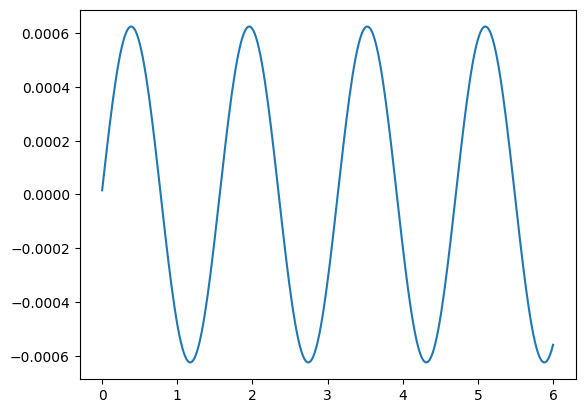

In [19]:
data=[]
data1=[]
for g0 in g0s:
    L = 100
    n = np.arange(0, L//2 )
    k = (2 * n + 1) * pi / L
    uks=[]
    vks=[]
    for ki in k:
        V0 = la.eigh(BdG(ki,g0))[1][:,1]
        uk = V0[0]*cos(2*w(ki,gf)*t)+1j*(a(ki,gf)*V0[0]+b(ki,gf)*V0[1])/w(ki,gf)*sin(2*w(ki,gf)*t)
        vk = -1j*V0[1]*cos(2*w(ki,gf)*t)+(b(ki,gf)*V0[0]-a(ki,gf)*V0[1])/w(ki,gf)*sin(2*w(ki,gf)*t)

        uks.append(uk)
        vks.append(vk)
    uks=array(uks)
    vks=array(vks)
    states = [[uks[:, i], vks[:, i], k] for i in range(len(t))]
    dat= [kz.sigma_general([0,1],s) for s in states]

    plot(t,dat)



In [37]:
data

[]

[]

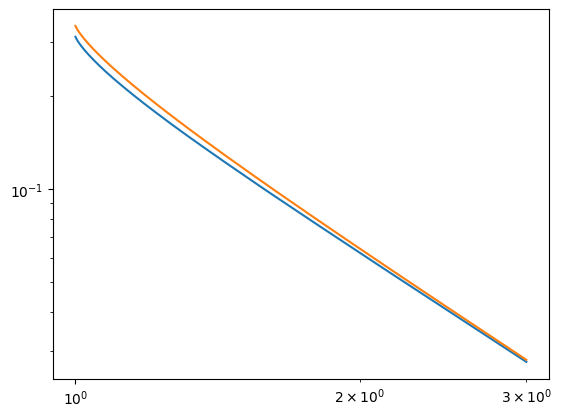

In [233]:
plot((g0s),array(data))
plot(g0s,array(data1)**(4/10))
#plot(g0s,data/g0s**-5.25/25)
loglog()